# Clustering com WineKMC 

** Frameworks de Software - IFRS Osório**  


## 1. Importação das bibliotecas

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


## 2. Pergunta de negócio


**Podemos segmentar clientes com base no padrão de aceitação das ofertas de vinho?**

A ideia é:
- cada linha final representar um cliente
- cada coluna representar uma oferta
- o valor indicar se o cliente aceitou aquela oferta


## 3. Leitura do arquivo Excel

In [2]:
arquivo = "WineKMC.xlsx"

offers = pd.read_excel(arquivo, sheet_name="OfferInformation")
transactions = pd.read_excel(arquivo, sheet_name="Transactions")

print("Dimensão de offers:", offers.shape)
print("Dimensão de transactions:", transactions.shape)


Dimensão de offers: (32, 7)
Dimensão de transactions: (324, 2)


## 4. Inspeção inicial

In [3]:
display(offers.head())
display(transactions.head())


,Offer #,Campaign,Varietal,Minimum Qty (kg),Discount (%),Origin,Past Peak
0,1,January,Malbec,72,56,France,False
1,2,January,Pinot Noir,72,17,France,False
2,3,February,Espumante,144,32,Oregon,True
3,4,February,Champagne,72,48,France,True
4,5,February,Cabernet Sauvignon,144,44,New Zealand,True


,Customer Last Name,Offer #
0,Smith,2
1,Smith,24
2,Johnson,17
3,Johnson,24
4,Johnson,26


In [4]:
print("Colunas de offers:")
print(offers.columns.tolist())

print("\nColunas de transactions:")
print(transactions.columns.tolist())


Colunas de offers:
['Offer #', 'Campaign', 'Varietal', 'Minimum Qty (kg)', 'Discount (%)', 'Origin', 'Past Peak']

Colunas de transactions:
['Customer Last Name', 'Offer #']


## 5. Padronização dos nomes das colunas

In [5]:
offers.columns = [c.strip().lower() for c in offers.columns]
transactions.columns = [c.strip().lower() for c in transactions.columns]

print("Colunas padronizadas de offers:")
print(offers.columns.tolist())

print("\nColunas padronizadas de transactions:")
print(transactions.columns.tolist())


Colunas padronizadas de offers:
['offer #', 'campaign', 'varietal', 'minimum qty (kg)', 'discount (%)', 'origin', 'past peak']

Colunas padronizadas de transactions:
['customer last name', 'offer #']


## 6. Definição explícita das colunas principais

 ### Definir explicitamente as colunas


In [6]:
offer_id_col = "offer #"
customer_col = "customer last name"
trans_offer_col = "offer #"

print("offer_id_col   =", offer_id_col)
print("customer_col   =", customer_col)
print("trans_offer_col=", trans_offer_col)


offer_id_col   = offer #
customer_col   = customer last name
trans_offer_col= offer #


## 7. Construção da matriz cliente × oferta

Neste dataset, a presença da linha em `Transactions` significa que o cliente aceitou a oferta.

Então vamos construir uma matriz binária:
- linha = cliente
- coluna = oferta
- valor = 1 se aceitou, 0 caso contrário


In [7]:
transactions["accepted"] = 1

customer_offer_matrix = transactions.pivot_table(
    index=customer_col,
    columns=trans_offer_col,
    values="accepted",
    aggfunc="max",
    fill_value=0
)

customer_offer_matrix = customer_offer_matrix.astype(int)

print("Shape da matriz cliente × oferta:", customer_offer_matrix.shape)
display(customer_offer_matrix.head())
display(customer_offer_matrix.tail())


Shape da matriz cliente × oferta: (100, 32)


offer #,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32
customer last name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Adams,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0
Allen,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
Anderson,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
Bailey,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
Baker,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0


offer #,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32
customer last name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Williams,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0
Wilson,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
Wood,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
Wright,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
Young,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1


## 8. Feature engineering

Vamos criar uma feature adicional:

- `total_accepted`: total de ofertas aceitas por cliente

Essa variável será mantida no clustering.


In [8]:
customer_features = customer_offer_matrix.copy()
customer_features["total_accepted"] = customer_offer_matrix.sum(axis=1)

display(customer_features.head())


offer #,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,total_accepted
customer last name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Adams,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,3
Allen,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,2
Anderson,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,2
Bailey,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2
Baker,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,4


## 9. Análise exploratória de `total_accepted`

In [9]:
customer_features["total_accepted"].describe()


count    100.000000
mean       3.240000
std        1.608814
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        9.000000
Name: total_accepted, dtype: float64

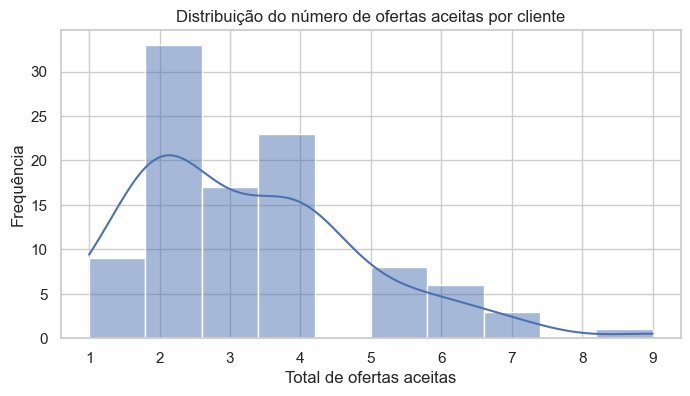

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(customer_features["total_accepted"], bins=10, kde=True)
plt.title("Distribuição do número de ofertas aceitas por cliente")
plt.xlabel("Total de ofertas aceitas")
plt.ylabel("Frequência")
plt.show()


## 10. Padronização

Como K-Means usa distância, é importante padronizar as variáveis.


In [11]:
customer_features.columns = customer_features.columns.astype(str)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_features)

print("Shape de X_scaled:", X_scaled.shape)


Shape de X_scaled: (100, 33)


## 11. Método do Elbow (Cotovelo)

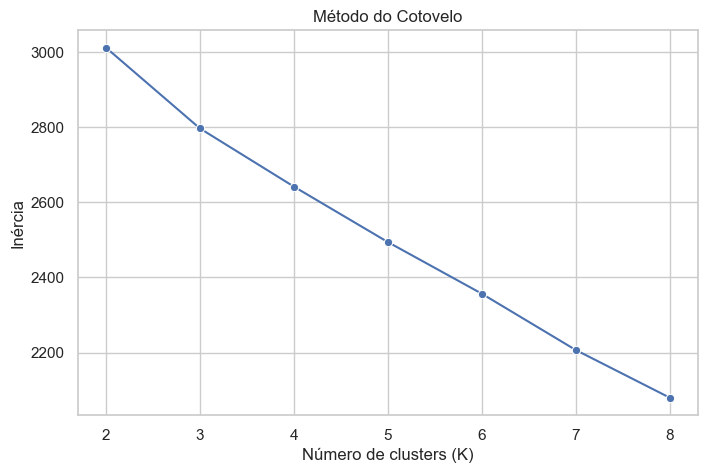

Melhor K pelo método do cotovelo: 3 (baseado na análise visual do gráfico)


In [12]:
inertia = []
K_values = range(2, 9)

with threadpool_limits(limits=1):
    for k in K_values:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X_scaled)
        inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
sns.lineplot(x=list(K_values), y=inertia, marker="o")
plt.title("Método do Cotovelo")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inércia")
plt.grid(True)
plt.show()
print("Melhor K pelo método do cotovelo: 3 (baseado na análise visual do gráfico)")


## 12. Método da Silhouette Score (Silhueta)

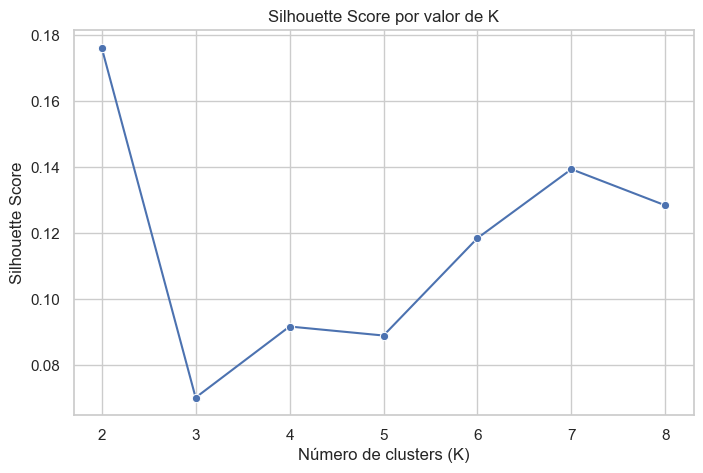

Melhor K pelo silhouette: 2


In [13]:
sil_scores = []

with threadpool_limits(limits=1):
    for k in K_values:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 5))
sns.lineplot(x=list(K_values), y=sil_scores, marker="o")
plt.title("Silhouette Score por valor de K")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

best_k = K_values[sil_scores.index(max(sil_scores))]
print("Melhor K pelo silhouette:", best_k)



## 13. Modelo final

Observação importante: os números dos clusters (`0`, `1`, `2`, ...) são **arbitrários**.
Eles não indicam ordem ou qualidade.


In [14]:
best_k = 3 # Escolha baseada na análise dos gráficos

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

customer_features["cluster"] = clusters
display(customer_features.head())


offer #,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,total_accepted,cluster
customer last name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Adams,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,3,2
Allen,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,2,0
Anderson,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,2,1
Bailey,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2,2
Baker,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,4,0


## 14. Distribuição dos clientes por cluster

In [15]:
cluster_counts = customer_features["cluster"].value_counts().sort_index()
display(cluster_counts)


cluster
0    52
1    14
2    34
Name: count, dtype: int64

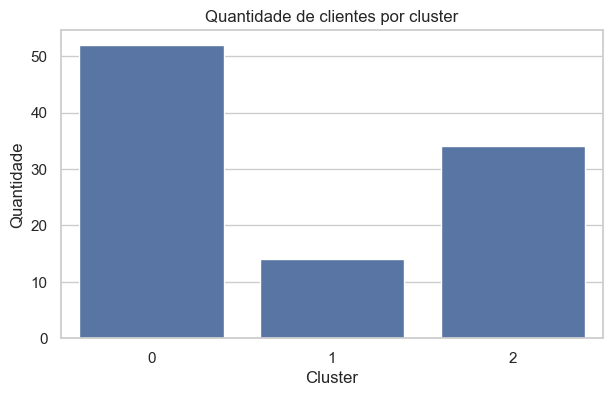

In [16]:
plt.figure(figsize=(7, 4))
sns.countplot(x="cluster", data=customer_features.reset_index())
plt.title("Quantidade de clientes por cluster")
plt.xlabel("Cluster")
plt.ylabel("Quantidade")
plt.show()


## 15. Visualização com PCA

#### O PCA projeta os dados em um espaço de menor dimensionalidade, maximizando a variância explicada, permitindo visualizar estruturas e padrões que seriam difíceis de observar em alta dimensão.
- Utilizamos PCA com 2 componentes para visualização dos dados em um gráfico bidimensional.
- Entretanto, essa redução preserva apenas parte da variância dos dados. Para análises mais completas, é possível utilizar mais componentes (ex: 5), aumentando a quantidade de informação preservada.
- Assim, há um trade-off entre visualização e fidelidade da representação dos dados.

In [17]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "pc1": X_pca[:, 0],
    "pc2": X_pca[:, 1],
    "cluster": clusters,
    "customer": customer_features.index
})

display(plot_df.head())
print(pca.explained_variance_ratio_) # mostra o quanto da informação original é capturada por cada componente principal
print("Soma das proporções de variância explicada:", sum(pca.explained_variance_ratio_))


,pc1,pc2,cluster,customer
0,-2.245334,-0.954239,2,Adams
1,0.276339,0.366050,0,Allen
2,-0.841394,2.917805,1,Anderson
3,-1.712138,-0.604134,2,Bailey
4,0.223492,-2.066346,0,Baker


[0.11693671 0.09205957]
Soma das proporções de variância explicada: 0.20899628124073388


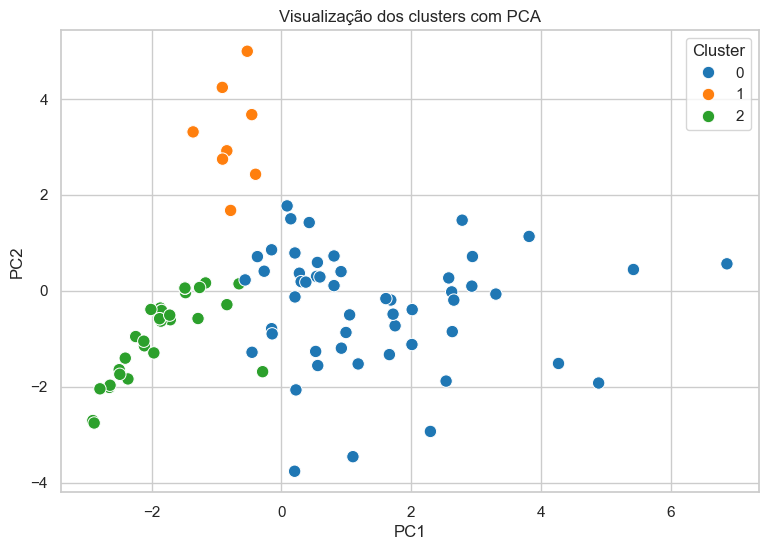

In [18]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df, x="pc1", y="pc2", hue="cluster", palette="tab10", s=80)
plt.title("Visualização dos clusters com PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()


## 16. Resumo estatístico dos clusters

In [19]:
cluster_summary = customer_features.groupby("cluster").mean().round(2)
display(cluster_summary)


offer #,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,total_accepted
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.19,0.10,0.12,0.23,0.08,0.21,0.10,0.08,0.19,0.12,0.23,0.08,0.00,0.17,0.12,0.1,0.0,0.02,0.1,0.12,0.06,0.4,0.1,0.00,0.12,0.10,0.15,0.10,0.02,0.1,0.33,0.08,3.87
1,0.00,0.36,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.5,0.00,0.0,0.00,0.00,0.0,0.0,0.86,0.00,0.71,0.00,0.00,0.00,0.0,0.00,0.00,2.43
2,0.00,0.00,0.00,0.00,0.00,0.03,0.41,0.47,0.00,0.03,0.03,0.03,0.18,0.00,0.00,0.0,0.0,0.38,0.0,0.00,0.03,0.0,0.0,0.00,0.00,0.00,0.03,0.03,0.47,0.5,0.00,0.00,2.62


## 17. Heatmap das ofertas por cluster

O heatmap abaixo mostra a aceitação média de cada oferta em cada cluster.


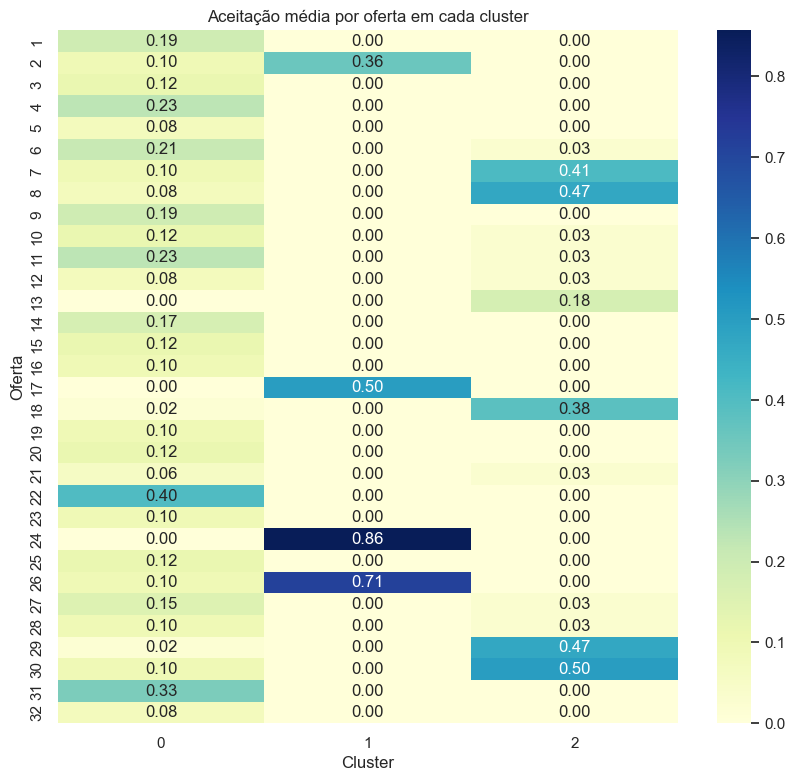

In [20]:
offer_by_cluster = customer_features.drop(columns=["total_accepted"]).groupby("cluster").mean().T

plt.figure(figsize=(10, 9))
sns.heatmap(offer_by_cluster, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Aceitação média por oferta em cada cluster")
plt.xlabel("Cluster")
plt.ylabel("Oferta")
plt.show()


## 18. Relacionando clusters às características das ofertas

Agora vamos juntar o comportamento médio dos clusters com os metadados das ofertas.


In [21]:
offers_small = offers.copy().rename(columns={offer_id_col: "offer_id"})
offers_small["offer_id"] = offers_small["offer_id"].astype(str)

base = customer_features.drop(columns=["total_accepted"]).copy()

offer_cluster = (
    base.groupby("cluster")
    .mean()
    .T
    .reset_index()
)

print("Colunas antes do rename:", offer_cluster.columns.tolist())

offer_cluster = offer_cluster.rename(
    columns={offer_cluster.columns[0]: "offer_id"}
)

offer_cluster["offer_id"] = offer_cluster["offer_id"].astype(str)

print("Colunas depois do rename:", offer_cluster.columns.tolist())

merged = offer_cluster.merge(offers_small, on="offer_id", how="left")
display(merged.head())

Colunas antes do rename: ['offer #', 0, 1, 2]
Colunas depois do rename: ['offer_id', 0, 1, 2]


,offer_id,0,1,2,campaign,varietal,minimum qty (kg),discount (%),origin,past peak
0,1,0.192308,0.000000,0.0,January,Malbec,72,56,France,False
1,2,0.096154,0.357143,0.0,January,Pinot Noir,72,17,France,False
2,3,0.115385,0.000000,0.0,February,Espumante,144,32,Oregon,True
3,4,0.230769,0.000000,0.0,February,Champagne,72,48,France,True
4,5,0.076923,0.000000,0.0,February,Cabernet Sauvignon,144,44,New Zealand,True


## 19. Exemplos de interpretação de negócio

Dependendo dos resultados, os clusters podem representar perfis como:

- clientes que aceitam poucas ofertas
- clientes mais sensíveis a desconto
- clientes que preferem certos tipos de vinho
- clientes mais ativos em campanhas específicas


## 20. Resumo

Neste notebook nós:

1. lemos o arquivo real do WineKMC
2. construímos a matriz cliente × oferta
3. criamos uma feature adicional (`total_accepted`)
4. aplicamos K-Means
5. escolhemos K com cotovelo e silhouette
6. visualizamos os grupos com PCA
7. interpretamos o comportamento dos clusters

Esse é um exemplo clássico de **aprendizado não supervisionado para segmentação de clientes**.


## 21.Bonus
#### Treinar com K = 3 e K = 4.
- Analisar quais ofertas são mais aceitas em cada cluster e se há um perfil distinto de clientes para cada tipo de vinho (varietal).

In [22]:
# Treinar K = 3 e K = 4 e comparar os perfis dos clusters para cada valor de K.

from sklearn.cluster import KMeans

results = {}

for k in [3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    df_k = customer_features.copy()
    df_k["cluster"] = labels

    results[k] = df_k

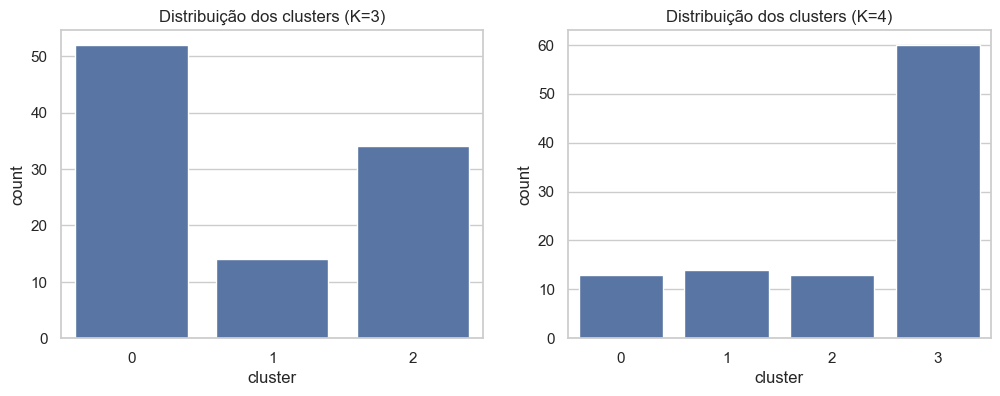

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,4))

for i, k in enumerate([3,4]):
    sns.countplot(x="cluster", data=results[k], ax=axes[i])
    axes[i].set_title(f"Distribuição dos clusters (K={k})")

plt.show()

In [24]:
for k in [3,4]:
    print(f"\n===== K = {k} =====")
    display(
        results[k]
        .groupby("cluster")["total_accepted"]
        .mean()
        .sort_values()
    )


===== K = 3 =====


cluster
1    2.428571
2    2.617647
0    3.865385
Name: total_accepted, dtype: float64


===== K = 4 =====


cluster
0    2.538462
3    2.633333
1    4.714286
2    5.153846
Name: total_accepted, dtype: float64

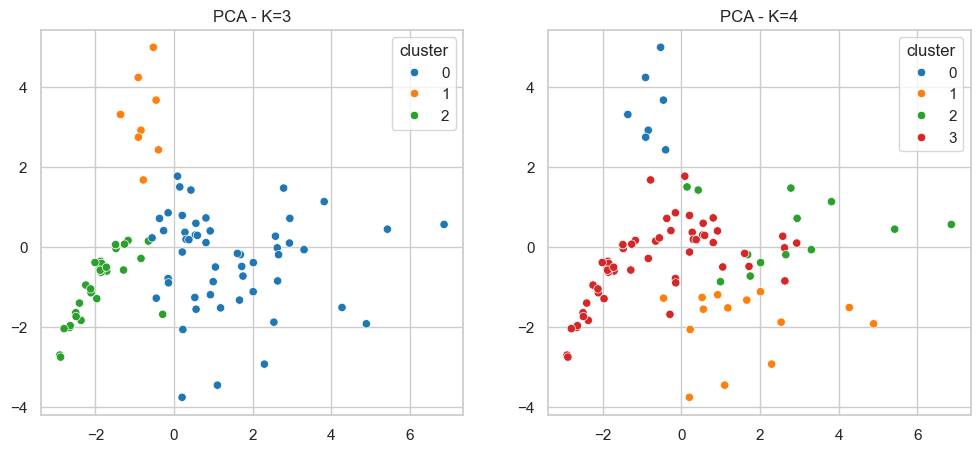

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

for i, k in enumerate([3,4]):
    sns.scatterplot(
        x=X_pca[:,0],
        y=X_pca[:,1],
        hue=results[k]["cluster"],
        palette="tab10",
        ax=axes[i]
    )
    axes[i].set_title(f"PCA - K={k}")

plt.show()

In [26]:
def interpretar_clusters(df, k):
    print(f"\n===== INTERPRETAÇÃO AUTOMÁTICA (K={k}) =====")

    resumo = df.groupby("cluster")["total_accepted"].mean()

    for cluster_id, valor in resumo.items():

        if valor < 2:
            perfil = "Baixo engajamento"
        elif valor < 5:
            perfil = "Engajamento moderado"
        else:
            perfil = "Alto engajamento"

        print(f"Cluster {cluster_id}: {perfil} (média={valor:.2f})")

In [27]:
for k in [3,4]:
    interpretar_clusters(results[k], k)


===== INTERPRETAÇÃO AUTOMÁTICA (K=3) =====
Cluster 0: Engajamento moderado (média=3.87)
Cluster 1: Engajamento moderado (média=2.43)
Cluster 2: Engajamento moderado (média=2.62)

===== INTERPRETAÇÃO AUTOMÁTICA (K=4) =====
Cluster 0: Engajamento moderado (média=2.54)
Cluster 1: Engajamento moderado (média=4.71)
Cluster 2: Alto engajamento (média=5.15)
Cluster 3: Engajamento moderado (média=2.63)


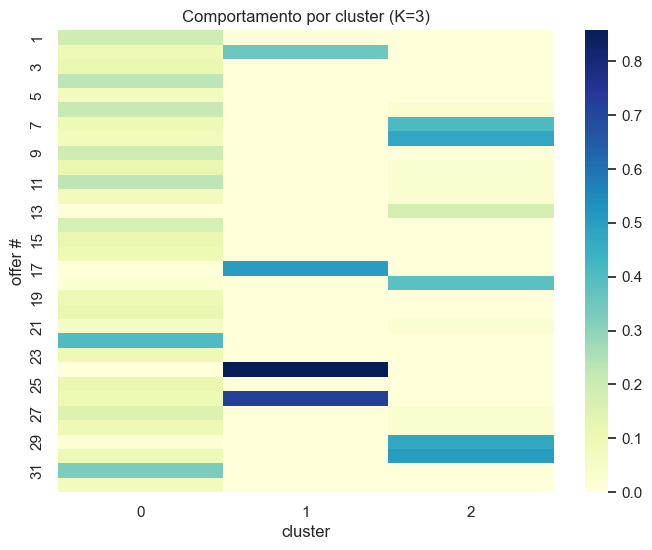

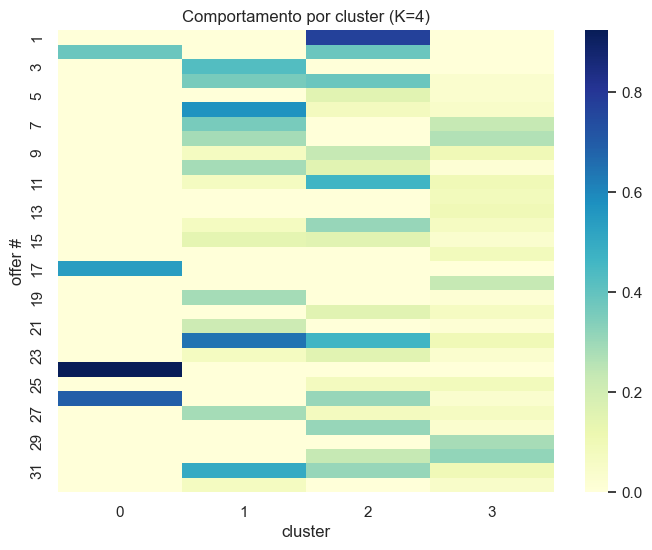

In [28]:
for k in [3,4]:
    plt.figure(figsize=(8,6))

    heat = results[k].drop(columns=["total_accepted"]).groupby("cluster").mean().T

    sns.heatmap(heat, cmap="YlGnBu")
    plt.title(f"Comportamento por cluster (K={k})")

    plt.show()

In [29]:
for k in [3, 4]:

    print(f"\n===== ANÁLISE COM OFERTAS (K={k}) =====")

    df_k = results[k].copy()
    base = df_k.drop(columns=["total_accepted"]).copy()

    offer_cluster = (
        base.groupby("cluster")
        .mean()
        .T
        .reset_index()
    )

    offer_cluster = offer_cluster.rename(
        columns={offer_cluster.columns[0]: "offer_id"}
    )

    offer_cluster["offer_id"] = offer_cluster["offer_id"].astype(str)

    offers_small = offers.copy().rename(columns={offer_id_col: "offer_id"})
    offers_small["offer_id"] = offers_small["offer_id"].astype(str)

    merged = offer_cluster.merge(
        offers_small,
        on="offer_id",
        how="left"
    )

    display(merged.head())

    print("\nMédia de desconto das ofertas mais aceitas por cluster:")

    cluster_cols = [c for c in merged.columns if str(c).isdigit()]

    for cluster_col in cluster_cols:
        top_offers = merged.sort_values(by=cluster_col, ascending=False).head(5)
        media_desconto = top_offers["discount (%)"].mean()

        print(f"Cluster {cluster_col}: média de desconto das 5 ofertas mais aceitas = {media_desconto:.2f}")


===== ANÁLISE COM OFERTAS (K=3) =====


,offer_id,0,1,2,campaign,varietal,minimum qty (kg),discount (%),origin,past peak
0,1,0.192308,0.000000,0.0,January,Malbec,72,56,France,False
1,2,0.096154,0.357143,0.0,January,Pinot Noir,72,17,France,False
2,3,0.115385,0.000000,0.0,February,Espumante,144,32,Oregon,True
3,4,0.230769,0.000000,0.0,February,Champagne,72,48,France,True
4,5,0.076923,0.000000,0.0,February,Cabernet Sauvignon,144,44,New Zealand,True



Média de desconto das ofertas mais aceitas por cluster:
Cluster 0: média de desconto das 5 ofertas mais aceitas = 74.20
Cluster 1: média de desconto das 5 ofertas mais aceitas = 45.00
Cluster 2: média de desconto das 5 ofertas mais aceitas = 55.20

===== ANÁLISE COM OFERTAS (K=4) =====


,offer_id,0,1,2,3,campaign,varietal,minimum qty (kg),discount (%),origin,past peak
0,1,0.000000,0.000000,0.769231,0.000000,January,Malbec,72,56,France,False
1,2,0.384615,0.000000,0.384615,0.000000,January,Pinot Noir,72,17,France,False
2,3,0.000000,0.428571,0.000000,0.000000,February,Espumante,144,32,Oregon,True
3,4,0.000000,0.357143,0.384615,0.033333,February,Champagne,72,48,France,True
4,5,0.000000,0.000000,0.153846,0.033333,February,Cabernet Sauvignon,144,44,New Zealand,True



Média de desconto das ofertas mais aceitas por cluster:
Cluster 0: média de desconto das 5 ofertas mais aceitas = 45.00
Cluster 1: média de desconto das 5 ofertas mais aceitas = 62.00
Cluster 2: média de desconto das 5 ofertas mais aceitas = 53.80
Cluster 3: média de desconto das 5 ofertas mais aceitas = 55.20


In [30]:
for k in [3, 4]:

    print(f"\n===== PERFIL POR VARIETAL (K={k}) =====")

    df_k = results[k].copy()
    base = df_k.drop(columns=["total_accepted"]).copy()

    offer_cluster = (
        base.groupby("cluster")
        .mean()
        .T
        .reset_index()
    )

    offer_cluster = offer_cluster.rename(
        columns={offer_cluster.columns[0]: "offer_id"}
    )

    offer_cluster["offer_id"] = offer_cluster["offer_id"].astype(str)

    offers_small = offers.copy().rename(columns={offer_id_col: "offer_id"})
    offers_small["offer_id"] = offers_small["offer_id"].astype(str)

    merged = offer_cluster.merge(
        offers_small,
        on="offer_id",
        how="left"
    )

    cluster_cols = [c for c in merged.columns if str(c).isdigit()]

    varietal_profile = merged.groupby("varietal")[cluster_cols].mean()

    display(varietal_profile)


===== PERFIL POR VARIETAL (K=3) =====


,0,1,2
varietal,,,
Cabernet Sauvignon,0.099359,0.000000,0.004902
Champagne,0.214286,0.000000,0.012605
Chardonnay,0.144231,0.000000,0.000000
Espumante,0.070513,0.000000,0.284314
Malbec,0.144231,0.000000,0.250000
Merlot,0.089744,0.000000,0.058824
Pinot Grigio,0.019231,0.000000,0.470588
Pinot Noir,0.048077,0.607143,0.000000
Prosecco,0.125000,0.000000,0.125000



===== PERFIL POR VARIETAL (K=4) =====


,0,1,2,3
varietal,,,,
Cabernet Sauvignon,0.000000,0.035714,0.141026,0.050000
Champagne,0.000000,0.336735,0.241758,0.061905
Chardonnay,0.000000,0.071429,0.192308,0.066667
Espumante,0.000000,0.238095,0.000000,0.166667
Malbec,0.000000,0.000000,0.500000,0.158333
Merlot,0.000000,0.023810,0.102564,0.083333
Pinot Grigio,0.000000,0.000000,0.000000,0.283333
Pinot Noir,0.634615,0.000000,0.173077,0.008333
Prosecco,0.000000,0.303571,0.057692,0.095833


# Sumário Executivo — Análise de Clustering (WineKMC)

## 1. Objetivo

Esta análise teve como objetivo segmentar clientes com base no comportamento de resposta às ofertas de vinho, utilizando técnicas de clustering não supervisionado, com foco na identificação de padrões de consumo e sensibilidade a incentivos promocionais.

---

## 2. Metodologia

Foi aplicada a técnica de **K-Means Clustering**, considerando diferentes valores de K (K=3 e K=4), a fim de avaliar o nível de granularidade da segmentação.

A análise foi baseada em:

- padrão de aceitação de ofertas por cliente  
- volume de respostas (total_accepted)  
- características das ofertas (desconto, varietal, campanha, origem)

---

## 3. Principais Resultados

### Segmentação com K = 3

A segmentação revelou três perfis distintos de clientes, fortemente influenciados pela sensibilidade ao desconto:

- **Alto engajamento / alta sensibilidade a desconto (~74%)**  
  Clientes altamente responsivos a promoções

- **Baixo engajamento / baixa sensibilidade (~45%)**  
  Clientes menos dependentes de incentivos

- **Engajamento moderado (~55%)**  
  Clientes com comportamento seletivo

---

### Segmentação com K = 4

A segmentação mais detalhada permitiu identificar subgrupos relevantes:

- **Alta sensibilidade a desconto (~62%)**  
  Clientes dependentes de promoções

- **Sensibilidade intermediária (~54–55%)**  
  Clientes com comportamento seletivo, porém heterogêneo

- **Baixa sensibilidade (~45%)**  
  Clientes mais estáveis, com menor dependência de desconto

Essa abordagem proporciona maior precisão na identificação de perfis de consumo.

---

## 4. Insights Estratégicos

A análise evidencia que:

- **O desconto é um fator determinante no comportamento de compra**, porém com impacto variável entre os segmentos  
- Existem clientes altamente sensíveis a preço (*price-driven*), que respondem apenas a incentivos agressivos  
- Há também clientes menos sensíveis, com maior valor percebido e potencial para estratégias premium  
- A segmentação permite compreender não apenas o volume de consumo, mas principalmente o **padrão de decisão de compra**

---

## 5. Análise de Produto (Varietal)

A integração com os dados de ofertas revelou padrões relevantes:

- Preferência por determinados tipos de vinho varia entre os clusters  
- Produtos como **Malbec e Champagne** apresentam maior aceitação em grupos sensíveis a desconto  
- Certos clusters demonstram afinidade específica por varietais como **Pinot Noir**

Esses resultados indicam que o comportamento de compra é influenciado tanto por preço quanto por preferência de produto.

---

## 6. Implicações de Negócio

A segmentação permite a definição de estratégias mais eficientes:

- **Clientes sensíveis a desconto**  
  → campanhas promocionais agressivas  

- **Clientes menos sensíveis**  
  → foco em valor, marca e experiência  

- **Clientes intermediários**  
  → estratégias híbridas e personalizadas  

Essa abordagem contribui para aumento da eficiência de campanhas e melhor alocação de recursos.

---

## 7. Conclusão

A aplicação de clustering revelou padrões consistentes de comportamento, permitindo a identificação de perfis distintos de clientes.

A principal contribuição da análise está na evidência de que:

> diferentes clientes respondem de maneira distinta a estímulos de preço e produto.

Essa segmentação fornece base sólida para estratégias de marketing mais direcionadas, com potencial de aumentar conversão, retenção e valor do cliente.